In [1]:
import re
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import pandas as pd
from nltk.corpus import stopwords
from wordcloud import WordCloud




In [2]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [4]:
df = pd.read_csv('../data/raw/video_captions_public_tik_tok.csv')
print(df.head())

              video_id                                            caption
0  7529246156723866935  hey dude friendly reminder that some days are ...
1  7508052741579623723  I’m never gonna see my kid again it's been 3 y...
2  7529863271709461778  i don't paint at all i don't need it i don't p...
3  7528849667799518519  So the thing I keep thinking about is, was it ...
4  7523993927809010975  I've made a decision. Alright. Uh, what decisi...


In [5]:
text = ' '.join(df['caption'].astype(str))
text

'hey dude friendly reminder that some days are hard to get out of bed and we do it anyway because we\'re strong and capable we can do uncomfortable things because we\'ve done so many uncomfortable things before I’m never gonna see my kid again it\'s been 3 years now since my son left and I don\'t know why it\'s getting harder but it is it\'s a lot harder I guess um this is the first year that we\'ve been alone his dad and I um just I guess the loneliness is really getting to me suicide man is such a it impacts the people in your life so much I just can\'t help but think if he would have just asked for help and said hey mom I don\'t feel worthy of life I feel like no one wants me around that you guys would be better off without me I think we would have found a way to help him i don\'t paint at all i don\'t need it i don\'t paint at all i don\'t need it So the thing I keep thinking about is, was it worth it to be happy for a little bit, even though it ended up sad? Or would it have been 

In [6]:
text = text.lower()
text = re.sub(r'[^A-Za-z\s]', '', text)  # Удаляем все, кроме букв
words = text.split()
words = [word for word in words if word not in stop_words and len(word) > 2]

In [7]:
word_freq = Counter(words)
freq_df = pd.DataFrame(word_freq.items(), columns=['Слово', 'Частота']).sort_values(by='Частота', ascending=False)

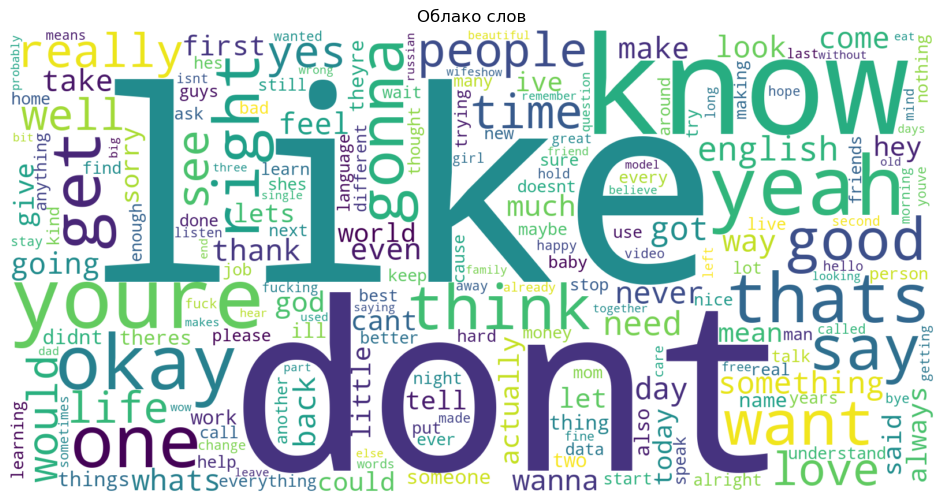

      Слово  Частота
51     like     2370
24     dont     1805
25     know     1472
176   youre     1335
240    yeah     1240
85     okay     1067
52      one      994
155   thats      871
6       get      848
17    gonna      735
275     say      734
324    want      732
372   right      732
44    think      710
119    good      690
39   people      678
99     time      672
35   really      642
313    love      624
18      see      596


In [10]:
wordcloud = WordCloud(width=1600, height=800, background_color='white').generate_from_frequencies(word_freq)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Облако слов")
plt.show()

print(freq_df.head(20))

In [9]:



# 2. Объединение всех субтитров в один текст


# 3. Очистка текста
text = text.lower()
text = re.sub(r'[^а-яa-z\s]', '', text)  # Удаляем все, кроме букв
words = text.split()
words = [word for word in words if word not in stop_words and len(word) > 2]

# 4. Подсчёт частоты слов
word_freq = Counter(words)
freq_df = pd.DataFrame(word_freq.items(), columns=['Слово', 'Частота']).sort_values(by='Частота', ascending=False)

# 5. Облако слов
